Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


Data collecting and Processing

In [2]:
# loading the csv data to a pandas dataframes
heart_data = pd.read_csv(r'C:\Users\GROVEER\Heart_Disease_App\heart_disease_data.csv')

In [3]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
#checking the missing values in the dataset
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# checking the distribution of target variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

Splitting the Features and Target

In [9]:
X = heart_data.drop(columns= 'target', axis=1)
Y = heart_data['target']

In [10]:
X.head()
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [11]:
# Number of rows and columns in the dataset
print(X.shape)
print(Y.shape)

(303, 13)
(303,)


In [12]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


Splitting the Data into Training data & Test data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify= Y, random_state=2)

In [14]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


In [15]:
corr = heart_data.corr()

ADD Feature Scaling

In [16]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

KNN Alogrithm

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.72      0.81        32
           1       0.75      0.93      0.83        29

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.84      0.82      0.82        61



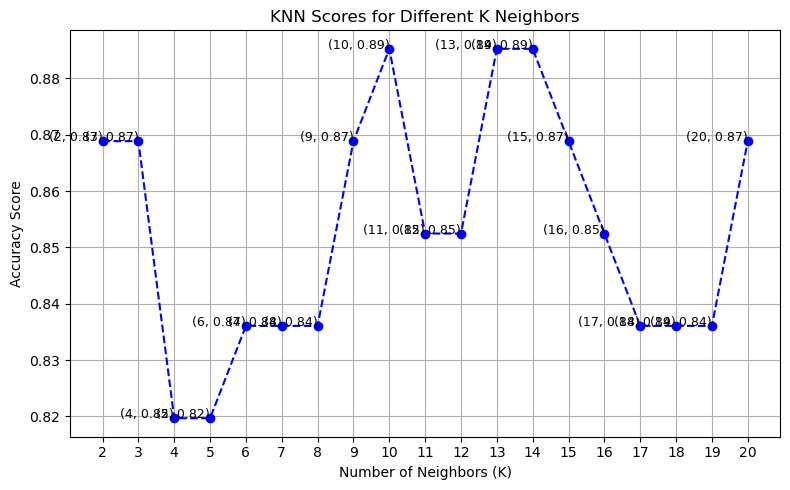

In [19]:
# Store scores for different k values
knn_scores = []
for k in range(2, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    score = knn.score(X_test, Y_test)
    knn_scores.append(score)

# Final KNN Model with k=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, Y_train)

# Predictions
Y_pred = knn_classifier.predict(X_test)

# Print classification report
print("Classification Report:\n", classification_report(Y_test, Y_pred))

# Plot the KNN scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 21), knn_scores, color='blue', marker='o', linestyle='dashed')

# Annotate each point with its (k, score)
for i, score in zip(range(2, 21), knn_scores):
    plt.text(i, score, f"({i}, {score:.2f})", fontsize=9, ha='right')

# Set x-ticks for better visibility
plt.xticks(range(2, 21))

# Labels and title
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('KNN Scores for Different K Neighbors')

plt.grid(True)
plt.tight_layout()
plt.show()

Support Vector Machine Algorithm

Kernel: linear, Accuracy: 0.87
Kernel: poly, Accuracy: 0.87
Kernel: rbf, Accuracy: 0.89
Kernel: sigmoid, Accuracy: 0.89
Final Model Accuracy: 0.8688524590163934


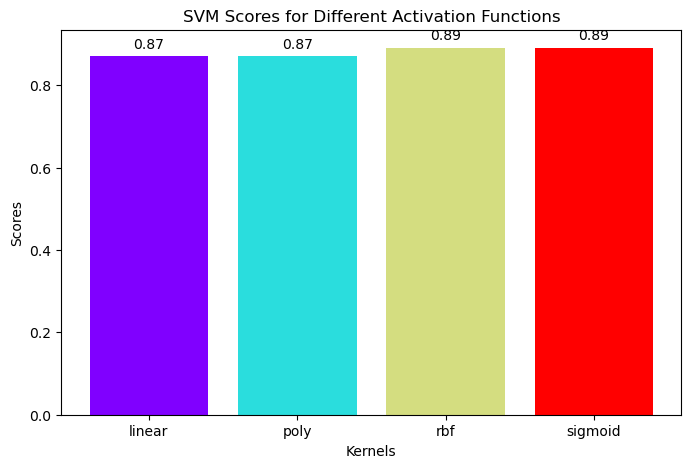

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Loop through different kernel types
for kernel in kernels:
    svc_classifier = SVC(kernel=kernel)
    svc_classifier.fit(X_train, Y_train)
    
    # Append accuracy score
    score = round(svc_classifier.score(X_test, Y_test), 2)
    svc_scores.append(score)

# Print scores for different kernels
for kernel, score in zip(kernels, svc_scores):
    print(f"Kernel: {kernel}, Accuracy: {score}")

# Train final model with the best kernel (e.g., 'linear')
best_kernel = kernels[0]  # Change this based on best accuracy
svc_classifier = SVC(kernel=best_kernel)
svc_classifier.fit(X_train, Y_train)

# Predictions and evaluation
svc_prediction_result = svc_classifier.predict(X_test)
print("Final Model Accuracy:", accuracy_score(Y_test, svc_prediction_result))


import matplotlib.cm as cm 

# Generate colors from the "rainbow" colormap
colors = cm.rainbow(np.linspace(0, 1, len(kernels)))

plt.figure(figsize=(8, 5))

# Create bar chart
plt.bar(kernels, svc_scores, color=colors)

# Add text labels for each bar
for i, score in enumerate(svc_scores):
    plt.text(i, score + 0.02, str(score), ha='center', fontsize=10)

# Labels and title
plt.xlabel('Kernels')
plt.ylabel('Scores')
plt.title('SVM Scores for Different Activation Functions')

# Show the plot
plt.show()



Decision Tree Classifer

In [21]:

dt_scores = []

# Loop through different max_features values
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features=i, random_state=0)
    dt_classifier.fit(X_train, Y_train)
    
    # Compute and store accuracy
    score = round(dt_classifier.score(X_test, Y_test), 2)
    dt_scores.append(score)

# Print completion message and scores
print("Done. Decision Tree Scores:", dt_scores)


Done. Decision Tree Scores: [0.69, 0.85, 0.84, 0.77, 0.72, 0.69, 0.77, 0.87, 0.72, 0.85, 0.8, 0.74, 0.89]


In [22]:
# Initialize Decision Tree with max_features=13
dt_classifier = DecisionTreeClassifier(max_features=13, random_state=0)

# Train the model
dt_classifier.fit(X_train, Y_train)


DecisionTreeClassifier(max_features=13, random_state=0)

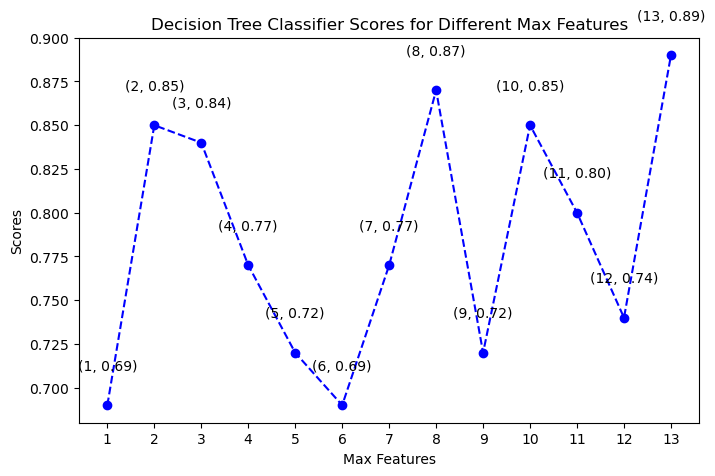

In [23]:

plt.figure(figsize=(8, 5))

# Plot Decision Tree scores
plt.plot(range(1, len(X.columns) + 1), dt_scores, color='blue', marker='o', linestyle='dashed')

# Add text labels for each point
for i, score in enumerate(dt_scores, start=1):
    plt.text(i, score + 0.02, f"({i}, {score:.2f})", ha='center', fontsize=10)

# Set x-ticks for better visibility
plt.xticks(range(1, len(X.columns) + 1))

# Labels and title
plt.xlabel('Max Features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier Scores for Different Max Features')

# Show the plot
plt.show()


Random Forest

n_estimators: 10, Accuracy: 0.85
n_estimators: 20, Accuracy: 0.89
n_estimators: 100, Accuracy: 0.9
n_estimators: 200, Accuracy: 0.9
n_estimators: 500, Accuracy: 0.9


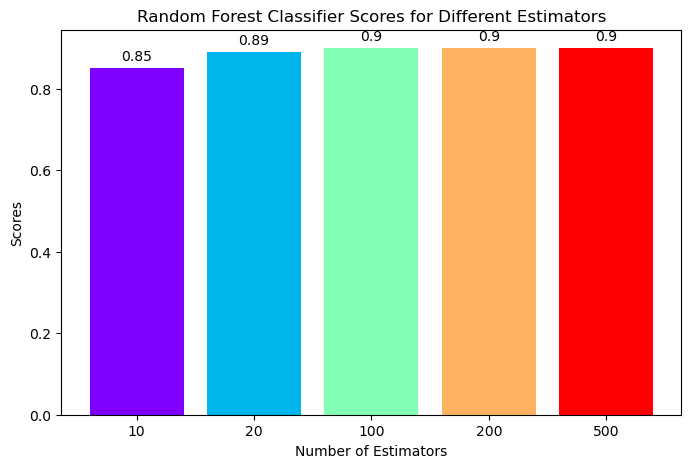

In [24]:

rf_scores = []
estimators = [10, 20, 100, 200, 500]

# Loop through different numbers of estimators
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators=i, random_state=0)
    rf_classifier.fit(X_train, Y_train)
    
    # Compute and store accuracy
    score = round(rf_classifier.score(X_test, Y_test), 2)
    rf_scores.append(score)

# Print results
for est, score in zip(estimators, rf_scores):
    print(f"n_estimators: {est}, Accuracy: {score}")



# Generate colors from the "rainbow" colormap
colors = cm.rainbow(np.linspace(0, 1, len(estimators)))
    
plt.figure(figsize=(8, 5))

# Create bar chart
plt.bar(range(len(estimators)), rf_scores, color=colors, width=0.8)

# Add text labels for each bar
for i, score in enumerate(rf_scores):
    plt.text(i, score + 0.02, str(score), ha='center', fontsize=10)

# Set x-ticks with proper estimator labels
plt.xticks(ticks=range(len(estimators)), labels=[str(estimator) for estimator in estimators])

# Labels and title
plt.xlabel('Number of Estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier Scores for Different Estimators')

# Show the plot
plt.show()


In [25]:
from sklearn.svm import SVC

final_model = SVC(kernel='linear')
final_model.fit(X_train, Y_train)

SVC(kernel='linear')

In [26]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)
input_data_df = pd.DataFrame([input_data], columns=X.columns)
prediction = final_model.predict(input_data_df)

C:\Users\GROVEER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [27]:
if prediction[0] == 0:
    print('The Person does not have Heart Disease')
else:
    print('The Person has Heart Disease')

The Person does not have Heart Disease


Save Trained Models

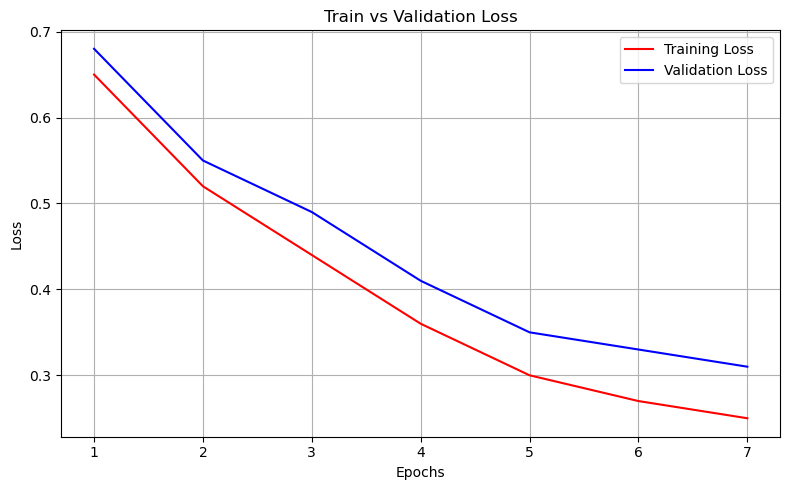

In [28]:
import matplotlib.pyplot as plt

# Example loss values (you can replace these with your actual loss lists)
train_loss = [0.65, 0.52, 0.44, 0.36, 0.30, 0.27, 0.25]
val_loss = [0.68, 0.55, 0.49, 0.41, 0.35, 0.33, 0.31]
epochs = range(1, len(train_loss) + 1)

# Plotting
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, 'r-', label='Training Loss')
plt.plot(epochs, val_loss, 'b-', label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
plt.savefig("train_vs_val_loss.png")


<Figure size 640x480 with 0 Axes>